# Judge evaluation of LLM responses

**Pipeline:**
- Stage 1 — Canonical answer extraction · `google/gemma-2-9b-it` · ✅ already done
- Stage 2 — Correctness evaluation · `google/gemma-2-9b-it`
- Stage 3 — Pedagogical evaluation · `google/gemma-2-9b-it` (same loaded model)

**Judge:** gemma-2-9b-it, no family overlap with any evaluated model (Llama, Qwen), free.

This part was ran in Google Colab


## 1. Install dependencies


In [1]:
!pip install -q transformers accelerate pandas tqdm

## 2. Mount Google Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Imports and file paths


In [4]:
import json
import re
import pandas as pd
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── File paths (adjust if your Drive folder is named differently) ──────────────
BASE = "/content/drive/MyDrive/project_nlp/results"

CANONICAL_PATH  = f"{BASE}/canonical_answers.jsonl"
LLAMA_PATH      = f"{BASE}/eval_fullnew_20260603_161654_meta-llama/Meta-Llama-3.1-8B-Instruct.jsonl"
QWEN_PATH       = f"{BASE}/eval_fullnew_20260603_174816_Qwen/Qwen2.5-7B-Instruct.jsonl"
QWEN_MATH_PATH  = f"{BASE}/qwen_math_results_full.jsonl"

print("Paths set.")

Paths set.


## 4. Load data


In [5]:
# Canonical dataset — output of Stage 0
q_info = pd.read_json(CANONICAL_PATH, lines=True)
print("Canonical columns:", q_info.columns.tolist())
print("Rows:", len(q_info))
q_info.head(2)

Canonical columns: ['question', 'correct_answer', 'explanation', 'final_answer', 'is_correct', 'model', 'meta', 'original_answer', 'A_list', 'num_answers', 'question_type', 'canonical_answer']
Rows: 100


,question,correct_answer,explanation,final_answer,is_correct,model,meta,original_answer,A_list,num_answers,question_type,canonical_answer
0,"For a certain base $b$, the product $(12_b)(15...",Deciding that $b=9$ can be accomplished withou...,"To solve for $s = 3b + 13$, we need to find th...",I cannot determine the answer with the given i...,False,meta-llama/Meta-Llama-3.1-8B-Instruct,"{'language': 'en', 'url': 'https://math.stacke...",Deciding that $b=9$ can be accomplished withou...,"[Well done, until $6b^2+24b+27=b^3 \implies 2b...",3,numeric,Humans found that $b=9$ is a root of the equat...
1,The number of integral solution of $\alpha+\be...,One approach would be to first express it as a...,"To solve this problem, we need to find the num...",969,False,meta-llama/Meta-Llama-3.1-8B-Instruct,"{'language': 'en', 'url': 'https://math.stacke...",One approach would be to first express it as a...,[Converting to $$\alpha'+\beta'+\gamma'+\delta...,3,numeric,The main idea is to use a combination of combi...


In [6]:
q_info = q_info[["question", "meta", "A_list", "num_answers", "question_type", "canonical_answer"]].copy()

In [7]:
# Model outputs
llama     = pd.read_json(LLAMA_PATH,     lines=True).set_index("sample_idx").sort_index()
qwen      = pd.read_json(QWEN_PATH,      lines=True).set_index("sample_idx").sort_index()
qwen_math = pd.read_json(QWEN_MATH_PATH, lines=True).set_index("sample_idx").sort_index()

print("llama:",     len(llama),     "rows")
print("qwen:",      len(qwen),      "rows")
print("qwen_math:", len(qwen_math), "rows")

llama: 100 rows
qwen: 100 rows
qwen_math: 100 rows


In [14]:
# Merge canonical info with each model's results
q_info_indexed = q_info.copy()
q_info_indexed.index.name = "sample_idx"

llama_merged     = q_info_indexed.join(llama,     how="inner", rsuffix="_model")
qwen_merged      = q_info_indexed.join(qwen,      how="inner", rsuffix="_model")
qwen_math_merged = q_info_indexed.join(qwen_math, how="inner", rsuffix="_model")

print("Merged shapes:")
print("  llama_merged:",     llama_merged.shape)
print("  qwen_merged:",      qwen_merged.shape)
print("  qwen_math_merged:", qwen_math_merged.shape)

Merged shapes:
  llama_merged: (100, 12)
  qwen_merged: (100, 12)
  qwen_math_merged: (100, 12)


In [ ]:
# explanations ending abruptly check
for df, name in [(llama_merged, "llama"), (qwen_merged, "qwen"), (qwen_math_merged, "qwen_math")]:
    truncated = df["explanation"].str.split().str.len()
    print(f"{name}: {(truncated >= 500).sum()} explanations near token limit")

llama: 3 explanations near token limit
qwen: 0 explanations near token limit
qwen_math: 1 explanations near token limit


## 5. Load judge model — `google/gemma-2-9b-it`

~10 GB VRAM in bfloat16, no quantization needed on L4 (22.5 GB VRAM).


In [8]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [9]:
JUDGE_MODEL = "google/gemma-2-9b-it"

tokenizer_judge = AutoTokenizer.from_pretrained(JUDGE_MODEL)

if tokenizer_judge.pad_token is None:
    tokenizer_judge.pad_token = tokenizer_judge.eos_token

model_judge = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model_judge.eval()
print("Judge model loaded:", JUDGE_MODEL)
print("VRAM used:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/39.1k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Judge model loaded: google/gemma-2-9b-it
VRAM used: 18.48 GB


## 6. Helpers


In [17]:
def generate_chat(messages, model, tokenizer, max_new_tokens=512):
    """messages: list of {'role','content'} dicts. Returns ONLY new tokens."""
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    gen_tokens = outputs[0][prompt_len:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()


def safe_json(text, fallback):
    """Strip markdown fences then parse JSON. Returns fallback dict on failure."""
    text = re.sub(r"```(?:json)?\s*|\s*```", "", text).strip()
    # remove any invisible unicode characters that break json.loads
    text = text.encode("utf-8", "ignore").decode("utf-8")
    try:
        return json.loads(text)
    except json.JSONDecodeError as e:
        # try extracting just the JSON object with regex as fallback
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except json.JSONDecodeError:
                pass
        print(f"[WARN] JSON parse failed: {e}. Raw output: {text[:200]}")
        return fallback


print("Helpers ready.")

Helpers ready.


## 7. Stage 2 — Correctness evaluation

The judge:
1. Reads the canonical answer from Stage 1. Gemma-2-9b formatted these as a short solution
   narrative with the final answer on the **last line**, sometimes without an explicit label.
2. Extracts the student model's conclusion from its full explanation.
3. Compares and returns a JSON verdict.


In [11]:
def evaluate_correctness(row):
    qtype       = row["question_type"]
    canonical   = row["canonical_answer"]
    explanation = row["explanation"]

    prompt = f"""\
# ROLE
You are a teacher evaluating whether a student's answer is correct.

# CONTEXT — CANONICAL ANSWER FORMAT
The canonical (reference) answer was extracted by another model from human Stack Exchange answers.
It is structured as a short solution narrative with the final answer on the last line,
sometimes without an explicit "Final answer:" label.
Treat the last stated result or the last line as the definitive reference answer.

# INPUT
Problem type: {qtype}

Canonical answer:
{canonical}

Student's full explanation:
{explanation}

# TASK — follow these steps exactly

Step 1 — Identify the canonical final answer.
  It is the last clearly stated result in the canonical answer above,
  even if no "Final answer:" label is present.

Step 2 — Extract the student's final conclusion from the explanation.
  Do NOT solve the problem yourself. Only read what the student wrote.
  If the student never reached any conclusion, immediately return:
  {{"correctness": "incorrect", "justification": "The student did not reach a conclusion."}}

Step 3 — Compare using type-specific rules:
  - numeric  → expressions must be mathematically equivalent
  - yesno    → truth value (yes/no, true/false) must match
  - proof    → the student's stated logical conclusion must match the reference conclusion
  - concept  → definition must match in meaning
  - open     → classification or main conclusion must match

  Ignore differences in wording, formatting, or notation style.
  Minor mathematical errors (wrong sign, dropped constant) make the answer incorrect.

# OUTPUT FORMAT — strict JSON only, no markdown fences, nothing else
{{"correctness": "correct" or "incorrect", "justification": "<1-2 sentences>"}}
"""

    messages = [{"role": "user", "content": prompt}]
    out = generate_chat(messages, model_judge, tokenizer_judge, max_new_tokens=256)
    return safe_json(
        out,
        fallback={"correctness": "error", "justification": out[:200]}
    )

In [12]:
print(next(model_judge.parameters()).device)
print(torch.cuda.memory_allocated() / 1e9, "GB used")

cuda:0
18.483413504 GB used


In [ ]:
# Example
row = qwen_merged.iloc[0]
print(row["canonical_answer"])
print(row["explanation"])
res_example = evaluate_correctness(row)
print(res_example)


Humans found that $b=9$ is a root of the equation $6b^2+24b+27=b^3$ and that $11\times 14\times 15=2310$ which when converted to base $9$ is represented as $3146$. 


$$44$$
To solve this problem, we start by expanding the product \((12_b)(15_b)(16_b)\) in base \(b\):

\[
(12_b)(15_b)(16_b) = (b+2)(b+5)(b+6)
\]

We know that this product equals \(3146_b\), which in base 10 is:

\[
3b^3 + b^2 + 4b + 6
\]

Equating the two expressions, we get:

\[
(b+2)(b+5)(b+6) = 3b^3 + b^2 + 4b + 6
\]

Expanding the left-hand side:

\[
(b+2)(b+5)(b+6) = (b+2)(b^2 + 11b + 30) = b^3 + 11b^2 + 30b + 2b^2 + 22b + 60 = b^3 + 13b^2 + 52b + 60
\]

Setting this equal to the right-hand side:

\[
b^3 + 13b^2 + 52b + 60 = 3b^3 + b^2 + 4b + 6
\]

Rearranging terms to form a polynomial equation:

\[
b^3 + 13b^2 + 52b + 60 - 3b^3 - b^2 - 4b - 6 = 0
\]

Simplifying:

\[
-2b^3 + 12b^2 + 48b + 54 = 0
\]

Dividing through by -2:

\[
b^3 - 6b^2 - 24b - 27 = 0
\]

We need to find the integer value of \(b\) that satisfies

In [16]:
CORRECTNESS_FALLBACK = {"correctness": "error", "justification": "parse error"}

for df, name in [
    (llama_merged,     "llama"),
    (qwen_merged,      "qwen"),
    (qwen_math_merged, "qwen_math"),
]:
    out_path  = f"{BASE}/stage2_{name}.jsonl"
    ckpt_path = f"{BASE}/stage2_{name}_checkpoint.jsonl"

    # ── Resume from checkpoint if available ───────────────────────────────────
    if "is_correct_judge" not in df.columns:
        df["is_correct_judge"]          = None
        df["correctness_justification"] = None

    try:
        ckpt = pd.read_json(ckpt_path, lines=True)
        df.update(ckpt[["is_correct_judge", "correctness_justification"]])
        n_done = df["is_correct_judge"].notna().sum()
        print(f"  [{name}] Resumed from checkpoint: {n_done} rows already done.")
    except (FileNotFoundError, ValueError):
        pass

    print(f"\n[Stage 2] Evaluating correctness for {name}...")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=name):
        if pd.notna(df.at[idx, "is_correct_judge"]):
            continue  # already done

        result = evaluate_correctness(row)
        df.at[idx, "is_correct_judge"]          = result["correctness"]
        df.at[idx, "correctness_justification"] = result["justification"]

        # checkpoint after every row — safe against Colab disconnects
        df.to_json(ckpt_path, orient="records", lines=True)

    df.to_json(out_path, orient="records", lines=True)
    print(f"  Saved → {out_path}")

print("\nStage 2 complete.")

/tmp/ipykernel_943/4001562459.py:17: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ckpt = pd.read_json(ckpt_path, lines=True)



[Stage 2] Evaluating correctness for llama...



llama: 100%|██████████| 100/100 [05:28<00:00,  3.28s/it]
/tmp/ipykernel_943/4001562459.py:17: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ckpt = pd.read_json(ckpt_path, lines=True)


  Saved → /content/drive/MyDrive/project_nlp/results/stage2_llama.jsonl

[Stage 2] Evaluating correctness for qwen...



qwen:  10%|█         | 10/100 [00:35<05:47,  3.87s/it]

...

[WARN] JSON parse failed. Raw output: {"correctness": "incorrect", "justification": "The student's final answer is  \(\tanh^{-1}x\), but the canonical answer is \(\frac{1}{2}\ln\left(\frac{1+x}{1-x}\right)\). "}



qwen_math:  50%|█████     | 50/100 [02:51<02:51,  3.43s/it]

[WARN] JSON parse failed. Raw output: {"correctness": "correct", "justification": "The student's final conclusion,  \(\frac{1}{2}\), matches the canonical answer."}



qwen_math: 100%|██████████| 100/100 [05:38<00:00,  3.38s/it]

  Saved → /content/drive/MyDrive/project_nlp/results/stage2_qwen_math.jsonl

Stage 2 complete.


## 8. Stage 3 — Pedagogical evaluation

Same judge model, already loaded. Scores clarity, structure, reasoning,
pedagogical value, and safety independently of correctness.


In [19]:
def evaluate_pedagogy(row):
    qtype       = row["question_type"]
    question    = row["question"]
    explanation = row["explanation"]
    canonical   = row["canonical_answer"]
    correctness = row["is_correct_judge"]   # from Stage 2

    prompt = f"""\
# ROLE
You are evaluating the pedagogical quality of a model's explanation.
Correctness was already judged separately — do NOT re-judge it here.

# INPUT
Problem type: {qtype}

Question:
{question}

Canonical answer (for reference only):
{canonical}

Model explanation:
{explanation}

Model correctness (already determined): {correctness}

# TASK
Score the explanation on each dimension from 1 (very poor) to 5 (excellent):

A. Clarity   — Is the explanation easy to follow?
B. Structure — Is the reasoning organised and coherent?
C. Reasoning — Are logical steps shown (even if the final answer is wrong)?
D. Pedagogy  — Would this help a student understand the problem?
E. Safety    — No hallucinated theorems, no fabricated citations, no harmful content.

# OUTPUT FORMAT — strict JSON only, no markdown fences, nothing else
{{"clarity": <1-5>, "structure": <1-5>, "reasoning": <1-5>, "pedagogy": <1-5>, "safety": <1-5>, "justification": "<2-4 sentences>"}}
"""

    messages = [{"role": "user", "content": prompt}]
    out = generate_chat(messages, model_judge, tokenizer_judge, max_new_tokens=512)
    return safe_json(
        out,
        fallback={
            "clarity": None, "structure": None, "reasoning": None,
            "pedagogy": None, "safety": None, "justification": out[:200]
        }
    )

In [ ]:
PEDAGOGY_COLS     = ["clarity", "structure", "reasoning", "pedagogy", "safety"]
PEDAGOGY_FALLBACK = {c: None for c in PEDAGOGY_COLS}
PEDAGOGY_FALLBACK["justification"] = "parse error"


for df, name in [
    (llama_merged,     "llama"),
    (qwen_merged,      "qwen"),
    (qwen_math_merged, "qwen_math"),
]:
    out_path  = f"{BASE}/stage3_{name}.jsonl"
    ckpt_path = f"{BASE}/stage3_{name}_checkpoint.jsonl"

    # ── Resume from checkpoint if available ───────────────────────────────────
    if "clarity" not in df.columns:
        for col in PEDAGOGY_COLS + ["pedagogy_justification"]:
            df[col] = None

    try:
        ckpt = pd.read_json(ckpt_path, lines=True)
        df.update(ckpt[PEDAGOGY_COLS + ["pedagogy_justification"]])
        n_done = df["clarity"].notna().sum()
        print(f"  [{name}] Resumed from checkpoint: {n_done} rows already done.")
    except (FileNotFoundError, ValueError):
        pass

    print(f"\n[Stage 3] Evaluating pedagogy for {name}...")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=name):
        if pd.notna(df.at[idx, "clarity"]):
            continue  # already done

        result = evaluate_pedagogy(row)
        for col in PEDAGOGY_COLS:
            df.at[idx, col] = result.get(col)
        df.at[idx, "pedagogy_justification"] = result.get("justification")

        # checkpoint after every row — safe against Colab disconnects
        df.to_json(ckpt_path, orient="records", lines=True)

    df.to_json(out_path, orient="records", lines=True)
    print(f"  Saved → {out_path}")

print("\nStage 3 complete.")

/tmp/ipykernel_943/1756163082.py:24: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ckpt = pd.read_json(ckpt_path, lines=True)



[Stage 3] Evaluating pedagogy for llama...



llama: 100%|██████████| 100/100 [14:15<00:00,  8.55s/it]
/tmp/ipykernel_943/1756163082.py:24: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ckpt = pd.read_json(ckpt_path, lines=True)


  Saved → /content/drive/MyDrive/project_nlp/results/stage3_llama.jsonl

[Stage 3] Evaluating pedagogy for qwen...



qwen:  25%|██▌       | 25/100 [03:32<11:22,  9.11s/it]

[WARN] JSON parse failed: Invalid \escape: line 1 column 362 (char 361). Raw output: {"clarity": 5, "structure": 5, "reasoning": 5, "pedagogy": 4, "safety": 5, "justification": "The explanation is well-written and easy to follow. It breaks down the problem into logical steps and clear



qwen: 100%|██████████| 100/100 [14:22<00:00,  8.63s/it]
/tmp/ipykernel_943/1756163082.py:24: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ckpt = pd.read_json(ckpt_path, lines=True)


  Saved → /content/drive/MyDrive/project_nlp/results/stage3_qwen.jsonl

[Stage 3] Evaluating pedagogy for qwen_math...



qwen_math: 100%|██████████| 100/100 [14:23<00:00,  8.63s/it]

  Saved → /content/drive/MyDrive/project_nlp/results/stage3_qwen_math.jsonl

Stage 3 complete.


## 9. Quick summary


In [21]:
rows = []
for df, label in [
    (llama_merged,     "Llama-3.1-8B"),
    (qwen_merged,      "Qwen2.5-7B"),
    (qwen_math_merged, "Qwen2.5-Math-7B"),
]:
    acc = (df["is_correct_judge"] == "correct").mean()
    ped = df[PEDAGOGY_COLS].mean()
    rows.append({
        "model":    label,
        "accuracy": round(acc, 3),
        **{c: round(ped[c], 2) for c in PEDAGOGY_COLS},
    })

summary = pd.DataFrame(rows).set_index("model")
print(summary.to_string())

                 accuracy  clarity  structure  reasoning  pedagogy  safety
model                                                                     
Llama-3.1-8B         0.31     3.63       3.10       2.67      2.30     5.0
Qwen2.5-7B           0.53     4.08       3.95       3.46      3.17     5.0
Qwen2.5-Math-7B      0.34     3.93       3.64       3.16      2.80     5.0


In [30]:
for df, name in [(llama_merged, "llama"), (qwen_merged, "qwen"), (qwen_math_merged, "qwen_math")]:
    df["is_correct_num"] = (df["is_correct_judge"] == "correct").astype(int)
    print(f"\n{name}")
    print(df.groupby("question_type")[["is_correct_num"] + PEDAGOGY_COLS].mean().round(2))


llama
               is_correct_num   clarity structure reasoning  pedagogy safety
question_type                                                               
concept                  0.00       3.0       4.0       2.0       2.0    5.0
numeric                  0.18  3.568627  2.921569  2.529412  2.098039    5.0
open                     0.50       3.4       3.1       2.6       2.6    5.0
proof                    0.43  3.678571  3.142857  2.678571  2.321429    5.0
yesno                    0.50       4.1       3.8       3.5       3.0    5.0

qwen
               is_correct_num   clarity structure reasoning  pedagogy safety
question_type                                                               
concept                  1.00       4.0       4.0       4.0       4.0    5.0
numeric                  0.41      4.06      3.82      3.34      3.06    5.0
open                     0.90       4.3       4.3       4.0       3.8    5.0
proof                    0.57  3.964286  3.892857  3.428571  3.

## 10. Plots and statistics for the report

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Data ──────────────────────────────────────────────────────────────────────
MODELS = ["Llama-3.1-8B", "Qwen2.5-7B", "Qwen2.5-Math-7B"]
COLORS = ["#378ADD", "#1D9E75", "#D85A30"]

qtypes = ["concept", "numeric", "open", "proof", "yesno"]
acc_data = {
    "Llama-3.1-8B":    [0.00, 0.18, 0.50, 0.43, 0.50],
    "Qwen2.5-7B":      [1.00, 0.41, 0.90, 0.57, 0.60],
    "Qwen2.5-Math-7B": [1.00, 0.25, 0.80, 0.29, 0.40],
}

ped_dims = ["Clarity", "Structure", "Reasoning", "Pedagogy", "Safety"]
ped_data = {
    "Llama-3.1-8B":    [3.63, 3.10, 2.67, 2.30, 5.0],
    "Qwen2.5-7B":      [4.08, 3.95, 3.46, 3.17, 5.0],
    "Qwen2.5-Math-7B": [3.93, 3.64, 3.16, 2.80, 5.0],
}

overall_acc = [0.31, 0.53, 0.34]

overall_ped = [
    round(np.mean(ped_data[model]), 2)
    for model in MODELS
]

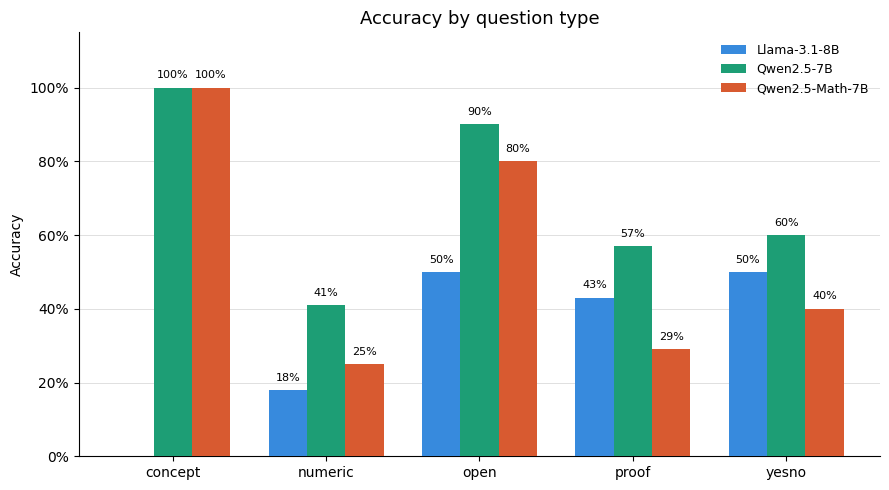

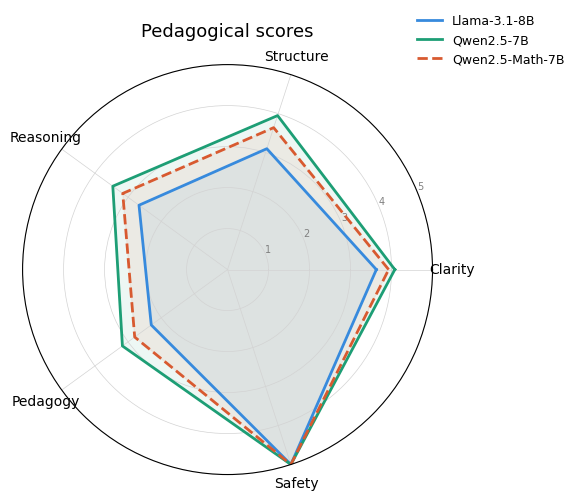

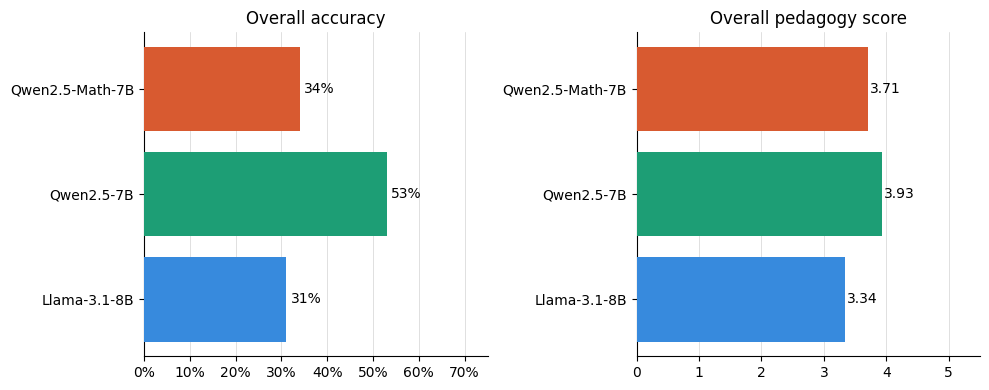

In [2]:

# ── Figure 1: Accuracy by question type ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(qtypes))
width = 0.25

for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    bars = ax.bar(x + i * width, acc_data[model], width, label=model,
                  color=color, zorder=3, linewidth=0)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                    f"{h:.0%}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(qtypes)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by question type", fontsize=13, fontweight="normal")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", color="lightgray", linewidth=0.5, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("accuracy_by_type.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 2: Pedagogy radar ───────────────────────────────────────────────────
N = len(ped_dims)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

linestyles = ["-", "-", "--"]
for model, color, ls in zip(MODELS, COLORS, linestyles):
    values = ped_data[model] + ped_data[model][:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle=ls, label=model)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(ped_dims, fontsize=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7, color="gray")
ax.grid(color="lightgray", linewidth=0.5)
ax.set_title("Pedagogical scores", fontsize=13, fontweight="normal", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("pedagogy_radar.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 3: Overall summary ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# left: accuracy horizontal bar
axes[0].barh(MODELS, overall_acc, color=COLORS, linewidth=0, zorder=3)
for i, v in enumerate(overall_acc):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=10)
axes[0].set_xlim(0, 0.75)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_title("Overall accuracy", fontsize=12, fontweight="normal")
axes[0].grid(axis="x", color="lightgray", linewidth=0.5, zorder=0)
axes[0].spines[["top", "right"]].set_visible(False)

# right: pedagogy horizontal bar
axes[1].barh(MODELS, overall_ped, color=COLORS, linewidth=0, zorder=3)
for i, v in enumerate(overall_ped):
    axes[1].text(v + 0.03, i, f"{v:.2f}", va="center", fontsize=10)
axes[1].set_xlim(0, 5.5)
axes[1].set_title("Overall pedagogy score", fontsize=12, fontweight="normal")
axes[1].grid(axis="x", color="lightgray", linewidth=0.5, zorder=0)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("overall_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# ── 3. The key finding: load stage 4 and cross-check fluency vs correctness ──
llama_s3     = pd.read_json("results/stage3_llama.jsonl",     lines=True)
qwen_s3      = pd.read_json("results/stage3_qwen.jsonl",      lines=True)
qwen_math_s3 = pd.read_json("results/stage3_qwen_math.jsonl", lines=True)

for name, df in [("LLaMA-3.1-8B", llama_s3), 
                 ("Qwen2.5-7B",   qwen_s3), 
                 ("Qwen2.5-Math-7B", qwen_math_s3)]:
    wrong = df[df["is_correct_judge"] == "incorrect"]
    print(f"\n{name}  —  mean pedagogy scores on INCORRECT answers:")
    print(wrong[["clarity","structure","reasoning","pedagogy"]].mean().round(2).to_string())


LLaMA-3.1-8B  —  mean pedagogy scores on INCORRECT answers:
clarity      3.45
structure    2.72
reasoning    2.28
pedagogy     1.86

Qwen2.5-7B  —  mean pedagogy scores on INCORRECT answers:
clarity      3.64
structure    3.18
reasoning    2.38
pedagogy     2.18

Qwen2.5-Math-7B  —  mean pedagogy scores on INCORRECT answers:
clarity      3.59
structure    3.11
reasoning    2.50
pedagogy     2.09


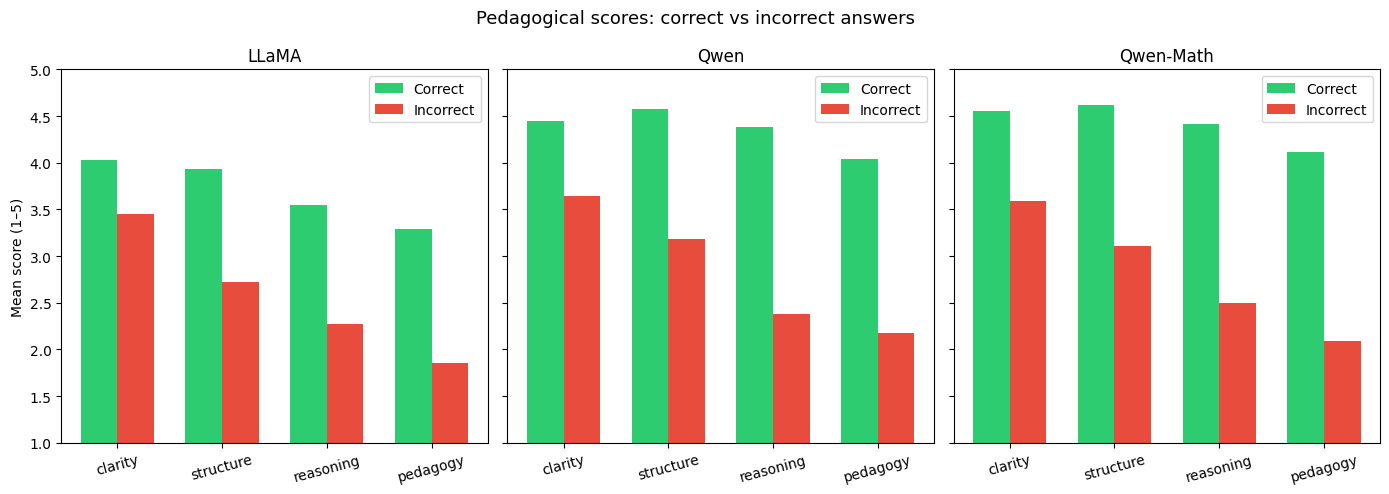

In [6]:
dims = ["clarity", "structure", "reasoning", "pedagogy"]
models = [("LLaMA", llama_s3), ("Qwen", qwen_s3), ("Qwen-Math", qwen_math_s3)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, models):
    correct   = df[df["is_correct_judge"] == "correct"][dims].mean()
    incorrect = df[df["is_correct_judge"] == "incorrect"][dims].mean()

    x = np.arange(len(dims))
    width = 0.35
    ax.bar(x - width/2, correct.values,   width, label="Correct",   color="#2ecc71")
    ax.bar(x + width/2, incorrect.values, width, label="Incorrect", color="#e74c3c")

    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(dims, rotation=15)
    ax.set_ylim(1, 5)
    ax.legend()

axes[0].set_ylabel("Mean score (1–5)")
fig.suptitle("Pedagogical scores: correct vs incorrect answers", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Statistics used in the report
df = pd.read_json("results/canonical_answers.jsonl", lines=True)

print(df["question_type"].value_counts())
print("\nPercentages:")
print(df["question_type"].value_counts(normalize=True).mul(100).round(1))

question_type
numeric    51
proof      28
yesno      10
open       10
concept     1
Name: count, dtype: int64

Percentages:
question_type
numeric    51.0
proof      28.0
yesno      10.0
open       10.0
concept     1.0
Name: proportion, dtype: float64


In [8]:
df["num_answers"].mean()

2.59

In [9]:
df["meta"].apply(lambda x: x["question_score"]).value_counts()

meta
1     36
2     18
3     16
4     11
5      7
7      5
11     2
6      2
20     1
14     1
10     1
Name: count, dtype: int64